1. a. Load the UTK face dataset: https://susanqq.github.io/UTKFace/

   b. Divide the dataset into training, validation and test sets (70%-15%-15%).

   c. Plot the distribution of the age labels on the training set

In [1]:
# Install the gdown library to download files from Google Drive
!pip install gdown

# Import the libraries we need for downloading and extracting files
import gdown  # Library to download files from Google Drive
import tarfile  # Library to work with .tar.gz files
import zipfile  # Library to work with .zip files
import os  # Library to work with files and folders

# Create a function to download and extract files from Google Drive
def download_and_extract(file_id, output_name, extract_to="UTKFace"):
    # Create the download URL using the file ID
    url = f"https://drive.google.com/uc?id={file_id}"
    # Show the user which URL we are downloading from
    print("Downloading from:", url)
    # Download the file from Google Drive
    gdown.download(url, output_name, quiet=False)

    # Try to extract the downloaded file
    # Check if the file is a compressed tar file
    if output_name.endswith(".tar.gz") or output_name.endswith(".tgz"):
        # Try to extract the tar file safely
        try:
            # Open the tar file for reading
            with tarfile.open(output_name, "r:gz") as tar:
                # Extract all files from the tar to the specified folder
                tar.extractall(extract_to)
            # Tell the user that extraction was successful
            print(f"Extracted {output_name} to {extract_to}/")
        except Exception as e:
            # If something goes wrong, catch the error
            print("Failed to extract tar.gz:", e)
    # Check if the file is a zip file
    elif output_name.endswith(".zip"):
        # Try to extract the zip file safely
        try:
            # Open the zip file for reading
            with zipfile.ZipFile(output_name, "r") as zf:
                # Extract all files from the zip to the specified folder
                zf.extractall(extract_to)
            # Tell the user that extraction was successful
            print(f"Extracted {output_name} to {extract_to}/")
        except Exception as e:
            # If something goes wrong, catch the error
            print("Failed to extract zip:", e)
    # If the file is not tar.gz or zip format
    else:
        # Tell the user we downloaded it but don't know how to extract it
        print(f"Downloaded {output_name}, but unknown format, please check manually.")

# Download the three dataset files from Google Drive
# Use one (or all) of these:
download_and_extract("1oj9ZWsLV2-k2idoW_nRSrLQLUP3hus3b", "file1.tar.gz")  # Download first dataset file
download_and_extract("19vdaXVRtkP-nyxz1MYwXiFsh_m_OL72b", "file2.tar.gz")  # Download second dataset file
download_and_extract("1mb5Z24TsnKI3ygNIlX6ZFiwUj0_PmpAW", "file3.tar.gz")  # Download third dataset file

Downloading...
From (original): https://drive.google.com/uc?id=1oj9ZWsLV2-k2idoW_nRSrLQLUP3hus3b
From (redirected): https://drive.google.com/uc?id=1oj9ZWsLV2-k2idoW_nRSrLQLUP3hus3b&confirm=t&uuid=a51394a4-f11d-4efc-a535-a0823858313b
To: /content/file1.tar.gz
100%|██████████| 57.0M/57.0M [00:00<00:00, 60.0MB/s]
/tmp/ipython-input-1184737140.py:27: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_to)


Extracted file1.tar.gz to UTKFace/


Downloading...
From (original): https://drive.google.com/uc?id=19vdaXVRtkP-nyxz1MYwXiFsh_m_OL72b
From (redirected): https://drive.google.com/uc?id=19vdaXVRtkP-nyxz1MYwXiFsh_m_OL72b&confirm=t&uuid=30ba4938-4792-41a6-b95e-07153c358839
To: /content/file2.tar.gz
100%|██████████| 459M/459M [00:04<00:00, 110MB/s]


Extracted file2.tar.gz to UTKFace/


Downloading...
From (original): https://drive.google.com/uc?id=1mb5Z24TsnKI3ygNIlX6ZFiwUj0_PmpAW
From (redirected): https://drive.google.com/uc?id=1mb5Z24TsnKI3ygNIlX6ZFiwUj0_PmpAW&confirm=t&uuid=4f29bdbb-f3c2-46e5-aeb1-29e2a089ddb9
To: /content/file3.tar.gz
100%|██████████| 874M/874M [00:09<00:00, 87.8MB/s]


Extracted file3.tar.gz to UTKFace/


In [2]:
# Import libraries needed for working with files and data
import pandas as pd  # Library to work with data tables

# Create a function to load the UTKFace dataset from a folder
def load_utkface_dataset(root_dir):
    # Create an empty list to store all the image information
    records = []
    # Go through all folders and files in the dataset directory
    for subdir, _, files in os.walk(root_dir):
        # Look at each file in the current folder
        for fname in files:
            # Only process files that are images (end with .jpg)
            if not fname.lower().endswith('.jpg'):
                # Skip files that are not images
                continue
            # Split the filename by underscore to get age, gender, and race
            parts = fname.split('_')
            # Make sure the filename has at least 3 parts (age_gender_race)
            if len(parts) < 3:
                # Skip files that don't have the right format
                continue
            # Try to convert the filename parts to numbers
            try:
                # Get the age from the first part of the filename
                age = int(parts[0])
                # Get the gender from the second part of the filename
                gender = int(parts[1])
                # Get the race from the third part of the filename
                race = int(parts[2])
            # If we can't convert to numbers, skip this file
            except ValueError:
                # Skip files that have invalid numbers in the filename
                continue
            # Create the full path to the image file
            fullpath = os.path.join(subdir, fname)
            # Add this image's information to our list
            records.append((fullpath, age, gender, race))
    # Convert our list into a data table and return it
    return pd.DataFrame(records, columns=['filepath', 'age', 'gender', 'race'])

# Load the dataset from the UTKFace folder
# Now load everything from UTKFace/
root = "UTKFace"  # The folder where our images are stored
df = load_utkface_dataset(root)  # Load all the image information into a data table
print("Total images:", len(df))  # Show how many images we have
print(df.head())  # Show the first few rows of our data table


Total images: 24102
                                     filepath  age  gender  race
0  UTKFace/part3/36_0_3_20170119201834796.jpg   36       0     3
1  UTKFace/part3/34_0_3_20170119200820284.jpg   34       0     3
2  UTKFace/part3/45_0_3_20170119204728031.jpg   45       0     3
3  UTKFace/part3/40_0_3_20170119204114783.jpg   40       0     3
4  UTKFace/part3/88_1_0_20170120230401803.jpg   88       1     0


In [3]:
# Import the function to split our data into training and testing sets
from sklearn.model_selection import train_test_split

# Split the data into training set (70%) and temporary set (30%)
# First split train vs temp (70% / 30%)
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, shuffle=True  # Use 30% for testing, mix up the data randomly
)

# Split the temporary set into validation set (15%) and test set (15%)
# Then split temp into validation and test (15% / 15%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, shuffle=True  # Use 50% of temp for testing, mix up the data randomly
)

# Show how many images are in each set
print("Train size:", len(train_df))  # Number of images for training
print("Validation size:", len(val_df))  # Number of images for validation
print("Test size:", len(test_df))  # Number of images for testing

# Show what percentage of the total data each set contains
print("\nFractions relative to full dataset:")
print(f"Train: {len(train_df)/len(df):.2%}")  # Percentage for training
print(f"Validation: {len(val_df)/len(df):.2%}")  # Percentage for validation
print(f"Test: {len(test_df)/len(df):.2%}")  # Percentage for testing



Train size: 16871
Validation size: 3615
Test size: 3616

Fractions relative to full dataset:
Train: 70.00%
Validation: 15.00%
Test: 15.00%


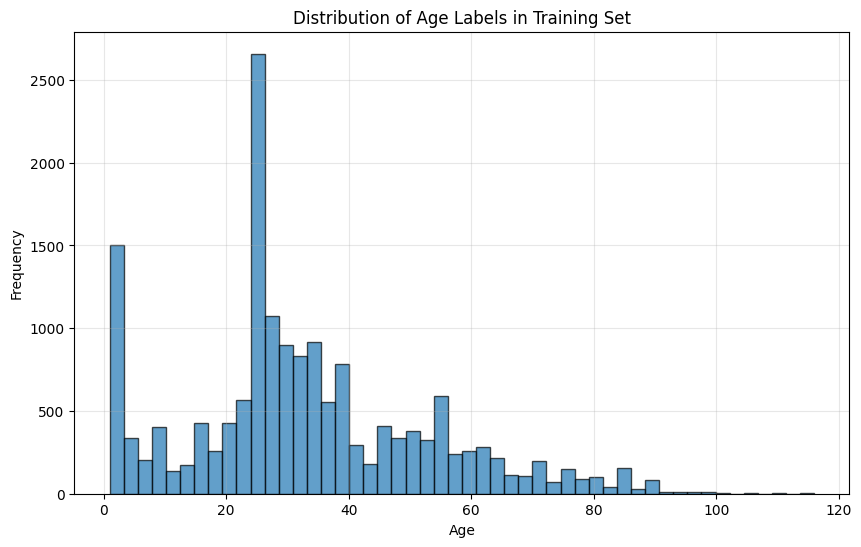

Age statistics for training set:
Mean age: 32.98
Median age: 29.00
Min age: 1
Max age: 116
Standard deviation: 20.09


In [4]:
# Import libraries for creating graphs and working with numbers
import matplotlib.pyplot as plt  # Library for creating graphs and charts
import numpy as np  # Library for working with numbers and arrays

# Create a graph showing how many people of each age we have in our training data
# Plot the distribution of age labels on the training set
plt.figure(figsize=(10, 6))  # Make the graph 10 inches wide and 6 inches tall
plt.hist(train_df['age'], bins=50, alpha=0.7, edgecolor='black')  # Create a histogram with 50 bars
plt.xlabel('Age')  # Label for the bottom of the graph
plt.ylabel('Frequency')  # Label for the left side of the graph
plt.title('Distribution of Age Labels in Training Set')  # Title at the top of the graph
plt.grid(True, alpha=0.3)  # Add grid lines to make it easier to read
plt.show()  # Display the graph

# Show some basic statistics about the ages in our training data
# Print some basic statistics
print("Age statistics for training set:")
print(f"Mean age: {train_df['age'].mean():.2f}")  # Average age
print(f"Median age: {train_df['age'].median():.2f}")  # Middle age when sorted
print(f"Min age: {train_df['age'].min()}")  # Youngest person
print(f"Max age: {train_df['age'].max()}")  # Oldest person
print(f"Standard deviation: {train_df['age'].std():.2f}")  # How spread out the ages are

2. a. Using PyTorch, design a CNN suitable for predicting the age of the persons from the     given faces as well as the ethnicity. Use ReLU activation and Max-pooling. Use the SimpleCNN architecture given above in the notebook. Experiment with varying depth and number of filters in each layer to achieve better performance.

   b. Design a joint loss function for the multi-task problem described above

In [5]:
# Import functional operations like activation functions
import torch.nn.functional as F
# Import dataset and data loading tools
from torch.utils.data import Dataset, DataLoader
# Import image transformation tools
from torchvision import transforms
# Import PIL library for image processing
from PIL import Image

# Create a custom dataset class for our face data
class UTKFaceDataset(Dataset):
    # Initialize the dataset with our data and optional image transformations
    def __init__(self, dataframe, transform=None):
        # Store the data and reset row numbers to start from 0
        self.dataframe = dataframe.reset_index(drop=True)
        # Store the image transformation function
        self.transform = transform

    # Return the total number of images in our dataset
    def __len__(self):
        return len(self.dataframe)

    # Get one image and its labels by index number
    def __getitem__(self, idx):
        # Get the row of data for this specific image
        row = self.dataframe.iloc[idx]

        # Open the image file and convert it to RGB color format
        image = Image.open(row['filepath']).convert('RGB')

        # Apply image transformations if they exist
        if self.transform:
            image = self.transform(image)

        # Convert age to a tensor (a special number format for PyTorch)
        age = torch.tensor(row['age'], dtype=torch.float32)
        # Convert race/ethnicity to a tensor for classification
        race = torch.tensor(row['race'], dtype=torch.long)

        # Return the image and its labels
        return image, age, race

# Define how to preprocess our images before training
transform = transforms.Compose([
    # Resize all images to 128x128 pixels
    transforms.Resize((128, 128)),
    # Convert image to tensor format (numbers that PyTorch can use)
    transforms.ToTensor(),
    # Normalize colors to make training more stable
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create three datasets: one for training, one for validation, one for testing
train_dataset = UTKFaceDataset(train_df, transform=transform)
val_dataset = UTKFaceDataset(val_df, transform=transform)
test_dataset = UTKFaceDataset(test_df, transform=transform)

# Create our neural network that can predict both age and ethnicity
class MultiTaskCNN(nn.Module):
    # Initialize the network with number of ethnicities to predict
    def __init__(self, num_ethnicities=5):
        # Call the parent class constructor
        super(MultiTaskCNN, self).__init__()

        # Create convolutional layers to extract features from images
        # First layer: takes 3 color channels, outputs 32 feature maps
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        # Second layer: takes 32 inputs, outputs 64 feature maps
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Third layer: takes 64 inputs, outputs 128 feature maps
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # Fourth layer: takes 128 inputs, outputs 256 feature maps
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

        # Max pooling layer to reduce image size by taking maximum values
        self.pool = nn.MaxPool2d(2, 2)
        # Dropout layer to prevent overfitting by randomly setting some neurons to 0
        self.dropout = nn.Dropout(0.5)

        # Calculate how many numbers we need for the fully connected layers
        # Image size goes: 128x128 -> 64x64 -> 32x32 -> 16x16 -> 8x8
        self.fc_input_size = 256 * 8 * 8

        # Create fully connected layers that make final predictions
        # First fully connected layer: takes all features, outputs 512 numbers
        self.fc1 = nn.Linear(self.fc_input_size, 512)
        # Second fully connected layer: takes 512 inputs, outputs 256 numbers
        self.fc2 = nn.Linear(512, 256)

        # Create separate prediction heads for each task
        # Age prediction head: takes 256 inputs, outputs 1 number (the age)
        self.age_head = nn.Linear(256, 1)

        # Ethnicity prediction head: takes 256 inputs, outputs number of ethnicities
        self.ethnicity_head = nn.Linear(256, num_ethnicities)

    # Define how data flows through our network
    def forward(self, x):
        # Pass image through first convolutional layer, apply ReLU activation, then pool
        x = self.pool(F.relu(self.conv1(x)))
        # Pass through second convolutional layer, apply ReLU activation, then pool
        x = self.pool(F.relu(self.conv2(x)))
        # Pass through third convolutional layer, apply ReLU activation, then pool
        x = self.pool(F.relu(self.conv3(x)))
        # Pass through fourth convolutional layer, apply ReLU activation, then pool
        x = self.pool(F.relu(self.conv4(x)))

        # Flatten the 2D feature maps into a 1D list of numbers
        x = x.view(x.size(0), -1)

        # Pass through first fully connected layer and apply ReLU activation
        x = F.relu(self.fc1(x))
        # Apply dropout to prevent overfitting
        x = self.dropout(x)
        # Pass through second fully connected layer and apply ReLU activation
        x = F.relu(self.fc2(x))
        # Apply dropout again
        x = self.dropout(x)

        # Make predictions for each task
        # Predict age (regression: output is a number)
        age_pred = self.age_head(x)
        # Predict ethnicity (classification: output is probability for each class)
        ethnicity_pred = self.ethnicity_head(x)

        # Return both predictions
        return age_pred, ethnicity_pred

# Create a loss function that combines age and ethnicity prediction errors
class JointLoss(nn.Module):
    # Initialize with weights for each task
    def __init__(self, age_weight=1.0, ethnicity_weight=1.0):
        # Call parent class constructor
        super(JointLoss, self).__init__()
        # How much to weight age prediction errors
        self.age_weight = age_weight
        # How much to weight ethnicity prediction errors
        self.ethnicity_weight = ethnicity_weight
        # Mean Squared Error loss for age prediction (good for numbers)
        self.mse_loss = nn.MSELoss()
        # Cross Entropy loss for ethnicity prediction (good for categories)
        self.ce_loss = nn.CrossEntropyLoss()

    # Calculate the total loss from both predictions
    def forward(self, age_pred, ethnicity_pred, age_target, ethnicity_target):
        # Calculate age prediction error using mean squared error
        age_loss = self.mse_loss(age_pred.squeeze(), age_target)

        # Calculate ethnicity prediction error using cross entropy
        ethnicity_loss = self.ce_loss(ethnicity_pred, ethnicity_target)

        # Combine both losses with their weights
        total_loss = self.age_weight * age_loss + self.ethnicity_weight * ethnicity_loss

        # Return total loss and individual losses
        return total_loss, age_loss, ethnicity_loss

# Set up the device (use GPU if available, otherwise use CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Print which device we are using
print(f"Using device: {device}")

# Create our model and move it to the chosen device
model = MultiTaskCNN(num_ethnicities=5).to(device)
# Create our loss function
joint_loss = JointLoss(age_weight=1.0, ethnicity_weight=1.0)

# Print information about our model
print("Model architecture:")
print(model)
# Print the total number of parameters (weights) in our model
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Model architecture:
MultiTaskCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=16384, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (age_head): Linear(in_features=256, out_features=1, bias=True)
  (ethnicity_head): Linear(in_features=256, out_features=5, bias=True)
)

Total parameters: 8,910,406


3. a. Train the CNN model using SGD with an appropriate minibatch size and learning rate. Record the validation loss obtained after every epoch. Save the trained model.

   b. Plot the training and validation losses.

Starting training with SGD (fixed version)...
Batch size: 32, Learning rate: 0.001

Epoch 1/20
--------------------------------------------------
Batch 0, Loss: 1510.3452, Age Loss: 1508.7292, Ethnicity Loss: 1.6159
Batch 50, Loss: 1664.2924, Age Loss: 1662.6370, Ethnicity Loss: 1.6554
Batch 100, Loss: 1121.5911, Age Loss: 1119.4634, Ethnicity Loss: 2.1277
Batch 150, Loss: 686.9594, Age Loss: 683.6388, Ethnicity Loss: 3.3206
Batch 200, Loss: 418.1339, Age Loss: 415.4797, Ethnicity Loss: 2.6542
Batch 250, Loss: 670.4271, Age Loss: 667.1332, Ethnicity Loss: 3.2939
Batch 300, Loss: 568.9131, Age Loss: 565.9656, Ethnicity Loss: 2.9474
Batch 350, Loss: 470.4063, Age Loss: 467.6464, Ethnicity Loss: 2.7599
Batch 400, Loss: 290.4162, Age Loss: 287.8929, Ethnicity Loss: 2.5233
Batch 450, Loss: 367.3341, Age Loss: 364.9426, Ethnicity Loss: 2.3915
Batch 500, Loss: 448.1514, Age Loss: 445.4232, Ethnicity Loss: 2.7283
Train Loss: 670.2061
Val Loss: 455.6982

Epoch 2/20
-----------------------------

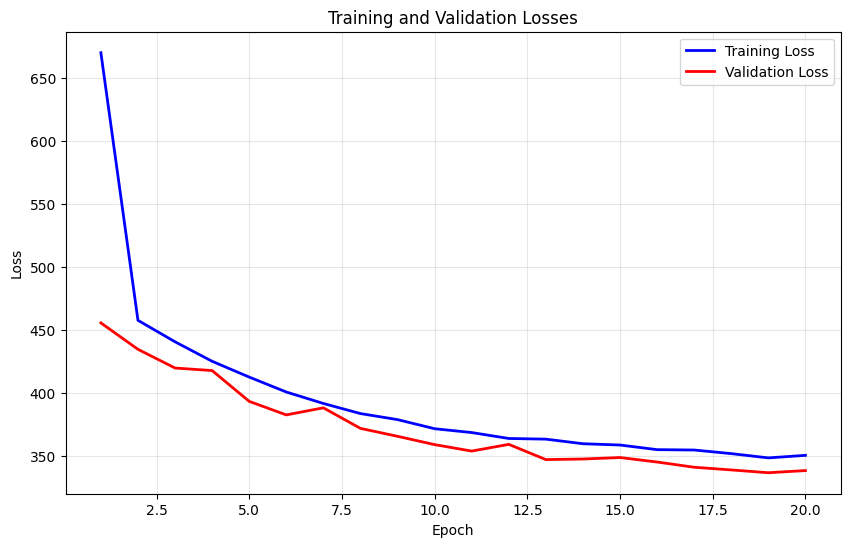


Final Training Loss: 350.5406
Final Validation Loss: 338.4430
Best Validation Loss: 336.7385 (Epoch 19)


In [6]:
# Import the PyTorch library for deep learning
import torch
# Import neural network modules from PyTorch
import torch.nn as nn
# Import functions for neural network operations
import torch.nn.functional as F
# Import optimization algorithms for training
import torch.optim as optim
# Import matplotlib for creating plots and graphs
import matplotlib.pyplot as plt
# Import numpy for numerical operations
import numpy as np

# Create data loaders with smaller batch size to avoid memory issues
# Set how many images to process at once (smaller number uses less memory)
batch_size = 32  # Reduced batch size
# Create a loader for training data that shuffles the order of images
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# Create a loader for validation data that does not shuffle the order
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Initialize SGD optimizer with LOWER learning rate and gradient clipping
# Set how fast the model learns (smaller number means slower but more stable learning)
learning_rate = 0.001  # Much lower learning rate to prevent instability
# Create an optimizer that will update the model weights during training
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-4)

# Lists to store losses for plotting
# Create empty list to store training loss values for each epoch
train_losses = []
# Create empty list to store validation loss values for each epoch
val_losses = []

# Training function with gradient clipping
# Define a function to train the model for one complete pass through all training data
def train_epoch(model, train_loader, optimizer, joint_loss, device):
    # Set the model to training mode (enables dropout and batch normalization)
    model.train()
    # Initialize variable to keep track of total loss for this epoch
    total_loss = 0

    # Loop through each batch of training data
    for batch_idx, (images, ages, ethnicities) in enumerate(train_loader):
        # Move the data to the GPU (or CPU) for processing
        images, ages, ethnicities = images.to(device), ages.to(device), ethnicities.to(device)

        # Clear any previous gradients before computing new ones
        optimizer.zero_grad()

        # Pass images through the model to get predictions for age and ethnicity
        age_pred, ethnicity_pred = model(images)
        # Calculate how wrong the predictions are compared to the true answers
        loss, age_loss, ethnicity_loss = joint_loss(age_pred, ethnicity_pred, ages, ethnicities)

        # Check for NaN loss (NaN means "Not a Number" - this indicates a problem)
        if torch.isnan(loss):
            # Print a warning message and skip this batch if loss is invalid
            print(f"NaN loss detected at batch {batch_idx}, skipping...")
            # Skip to the next batch without updating the model
            continue

        # Calculate gradients (how much to change each weight to reduce the loss)
        loss.backward()

        # Gradient clipping to prevent exploding gradients (limit how big the changes can be)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update the model weights based on the calculated gradients
        optimizer.step()

        # Add this batch's loss to the total loss for this epoch
        total_loss += loss.item()

        # Print progress every 50 batches to see how training is going
        if batch_idx % 50 == 0:  # More frequent logging
            print(f'Batch {batch_idx}, Loss: {loss.item():.4f}, Age Loss: {age_loss.item():.4f}, Ethnicity Loss: {ethnicity_loss.item():.4f}')

    # Return the average loss for this epoch (total loss divided by number of batches)
    return total_loss / len(train_loader)

# Validation function
# Define a function to test the model on validation data (data it hasn't seen during training)
def validate(model, val_loader, joint_loss, device):
    # Set the model to evaluation mode (disables dropout and batch normalization)
    model.eval()
    # Initialize variable to keep track of total loss for validation
    total_loss = 0

    # Disable gradient calculation during validation (we don't need to update weights)
    with torch.no_grad():
        # Loop through each batch of validation data
        for images, ages, ethnicities in val_loader:
            # Move the data to the GPU (or CPU) for processing
            images, ages, ethnicities = images.to(device), ages.to(device), ethnicities.to(device)

            # Pass images through the model to get predictions for age and ethnicity
            age_pred, ethnicity_pred = model(images)
            # Calculate how wrong the predictions are compared to the true answers
            loss, age_loss, ethnicity_loss = joint_loss(age_pred, ethnicity_pred, ages, ethnicities)

            # Only add the loss to total if it's a valid number (not NaN)
            if not torch.isnan(loss):
                # Add this batch's loss to the total loss for validation
                total_loss += loss.item()

    # Return the average loss for validation (total loss divided by number of batches)
    return total_loss / len(val_loader)

# Reinitialize the model to start fresh
# Create a new model that can predict both age and ethnicity
model = MultiTaskCNN(num_ethnicities=5).to(device)
# Create a loss function that combines age and ethnicity prediction errors
joint_loss = JointLoss(age_weight=1.0, ethnicity_weight=1.0)
# Create an optimizer to update the model weights during training
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-4)

# Train the model
# Set how many times to go through the entire training dataset
num_epochs = 20
# Print a message to show training is starting
print("Starting training with SGD (fixed version)...")
# Print the training settings so we can see what parameters are being used
print(f"Batch size: {batch_size}, Learning rate: {learning_rate}")

# Loop through each epoch (one complete pass through all training data)
for epoch in range(num_epochs):
    # Print which epoch we are currently on
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    # Print a line of dashes to separate each epoch visually
    print('-' * 50)

    # Training
    # Train the model for one epoch and get the average training loss
    train_loss = train_epoch(model, train_loader, optimizer, joint_loss, device)

    # Validation
    # Test the model on validation data and get the average validation loss
    val_loss = validate(model, val_loader, joint_loss, device)

    # Store losses
    # Add the training loss for this epoch to our list
    train_losses.append(train_loss)
    # Add the validation loss for this epoch to our list
    val_losses.append(val_loss)

    # Print the training loss for this epoch (rounded to 4 decimal places)
    print(f'Train Loss: {train_loss:.4f}')
    # Print the validation loss for this epoch (rounded to 4 decimal places)
    print(f'Val Loss: {val_loss:.4f}')

    # Early stopping if loss becomes NaN
    # Check if either loss is invalid (NaN means "Not a Number")
    if np.isnan(train_loss) or np.isnan(val_loss):
        # Print a message explaining why training stopped
        print("Training stopped due to NaN loss")
        # Exit the training loop early
        break

# Save the trained model
# Save all the important information about the trained model to a file
torch.save({
    # Save the model's learned weights and parameters
    'model_state_dict': model.state_dict(),
    # Save the optimizer's state (for resuming training later if needed)
    'optimizer_state_dict': optimizer.state_dict(),
    # Save the list of training losses for each epoch
    'train_losses': train_losses,
    # Save the list of validation losses for each epoch
    'val_losses': val_losses,
    # Save how many epochs we trained for
    'num_epochs': num_epochs,
    # Save the batch size we used
    'batch_size': batch_size,
    # Save the learning rate we used
    'learning_rate': learning_rate
# Save everything to a file called 'utkface_multitask_model.pth'
}, 'utkface_multitask_model.pth')

# Print a message confirming the model was saved successfully
print("Model saved as 'utkface_multitask_model.pth'")

# Plot training and validation losses
# Create a new figure for the plot with a specific size (10 inches wide, 6 inches tall)
plt.figure(figsize=(10, 6))
# Create a list of epoch numbers (1, 2, 3, etc.) for the x-axis
epochs = range(1, len(train_losses) + 1)
# Plot the training losses as a blue line
plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
# Plot the validation losses as a red line
plt.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
# Add a label to the x-axis
plt.xlabel('Epoch')
# Add a label to the y-axis
plt.ylabel('Loss')
# Add a title to the plot
plt.title('Training and Validation Losses')
# Show a legend to identify which line is which
plt.legend()
# Add a grid to make the plot easier to read
plt.grid(True, alpha=0.3)
# Display the plot
plt.show()

# Print final results
# Check if we have loss values to print
if train_losses and val_losses:
    # Print the final training loss (the last value in the list)
    print(f"\nFinal Training Loss: {train_losses[-1]:.4f}")
    # Print the final validation loss (the last value in the list)
    print(f"Final Validation Loss: {val_losses[-1]:.4f}")
    # Print the best (lowest) validation loss and which epoch it occurred in
    print(f"Best Validation Loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses))+1})")

4.  a. Load the trained model and evaluate the model on the test set to report the following: Classification report for ethnicity classification (accuracy, precision, recall). $R^2$ score for age regression

    b. Show the scatter plot of the predicted age labels vs. the corresponding ground truths on the test set.  

Model loaded successfully!
Training was done for 20 epochs
Final training loss: 350.5406
Final validation loss: 338.4430
Evaluating on test set...
Processed batch 0/113
Processed batch 50/113
Processed batch 100/113

Test set size: 3616 samples

TASK 4a: MODEL EVALUATION RESULTS

1. ETHNICITY CLASSIFICATION RESULTS:
----------------------------------------
Overall Accuracy: 0.4284 (42.84%)

Detailed Classification Report:
              precision    recall  f1-score   support

       White       0.43      1.00      0.60      1549
       Black       0.00      0.00      0.00       695
       Asian       0.00      0.00      0.00       546
      Indian       0.00      0.00      0.00       609
      Others       0.00      0.00      0.00       217

    accuracy                           0.43      3616
   macro avg       0.09      0.20      0.12      3616
weighted avg       0.18      0.43      0.26      3616


2. AGE REGRESSION RESULTS:
----------------------------------------
R² Score: 0.1947

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


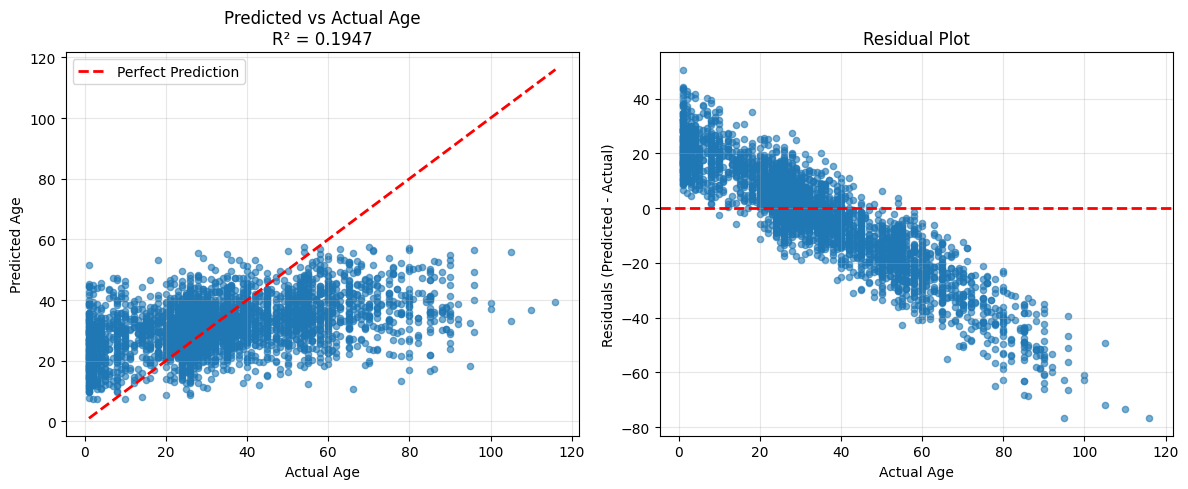


Sample Predictions:
------------------------------
Sample 274: Actual Age=3, Predicted Age=26.3, Actual Ethnicity=Asian, Predicted Ethnicity=White
Sample 2139: Actual Age=40, Predicted Age=40.0, Actual Ethnicity=Asian, Predicted Ethnicity=White
Sample 3531: Actual Age=45, Predicted Age=43.6, Actual Ethnicity=Indian, Predicted Ethnicity=White
Sample 338: Actual Age=1, Predicted Age=33.7, Actual Ethnicity=Indian, Predicted Ethnicity=White
Sample 2604: Actual Age=43, Predicted Age=50.9, Actual Ethnicity=White, Predicted Ethnicity=White
Sample 1317: Actual Age=70, Predicted Age=37.4, Actual Ethnicity=White, Predicted Ethnicity=White
Sample 2417: Actual Age=27, Predicted Age=36.0, Actual Ethnicity=White, Predicted Ethnicity=White
Sample 168: Actual Age=45, Predicted Age=33.3, Actual Ethnicity=White, Predicted Ethnicity=White
Sample 1224: Actual Age=46, Predicted Age=30.2, Actual Ethnicity=Indian, Predicted Ethnicity=White
Sample 66: Actual Age=15, Predicted Age=28.8, Actual Ethnicity=White

In [10]:
# Import functions to measure how good our model is
from sklearn.metrics import classification_report, r2_score, accuracy_score
# Import DataLoader to handle our test data
from torch.utils.data import DataLoader

# This function loads a model that was already trained before
def load_trained_model(model_path, device):
    # Create a new model with the same structure as the trained one
    # num_ethnicities=5 means we can predict 5 different ethnicities
    model = MultiTaskCNN(num_ethnicities=5).to(device)

    # Load the saved model file from the computer
    checkpoint = torch.load(model_path, map_location=device)
    # Put the trained weights into our new model
    model.load_state_dict(checkpoint['model_state_dict'])

    # Tell the user that everything worked
    print("Model loaded successfully!")
    # Show how many times the model was trained
    print(f"Training was done for {checkpoint['num_epochs']} epochs")
    # Show the final training error (lower is better)
    print(f"Final training loss: {checkpoint['train_losses'][-1]:.4f}")
    # Show the final validation error (lower is better)
    print(f"Final validation loss: {checkpoint['val_losses'][-1]:.4f}")

    # Give back the loaded model
    return model

# Choose whether to use GPU (faster) or CPU (slower) for calculations
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Load our trained model from the file
model = load_trained_model('utkface_multitask_model.pth', device)
# Tell the model we are testing, not training (this changes how it works)
model.eval()  # Set to evaluation mode

# Prepare our test data in small groups (batches) for testing
# batch_size=32 means we test 32 images at once
# shuffle=False means we don't mix up the order of images
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# This function tests how good our model is on new data
def evaluate_model(model, test_loader, device):
    # Make sure the model is in testing mode
    model.eval()

    # Create empty lists to store all our predictions and correct answers
    all_age_predictions = []  # What the model thinks the ages are
    all_age_targets = []      # What the actual ages are
    all_ethnicity_predictions = []  # What the model thinks the ethnicities are
    all_ethnicity_targets = []      # What the actual ethnicities are

    # Tell the user we are starting to test
    print("Evaluating on test set...")

    # Turn off gradient calculations to save memory and speed
    with torch.no_grad():
        # Go through each batch of test images
        for batch_idx, (images, ages, ethnicities) in enumerate(test_loader):
            # Move the data to the same device as our model (GPU or CPU)
            images, ages, ethnicities = images.to(device), ages.to(device), ethnicities.to(device)

            # Ask the model to predict ages and ethnicities for these images
            age_pred, ethnicity_pred = model(images)

            # Save the age predictions and correct ages
            all_age_predictions.extend(age_pred.cpu().numpy().flatten())
            all_age_targets.extend(ages.cpu().numpy())

            # Find the ethnicity with the highest probability (most likely answer)
            _, predicted_ethnicity = torch.max(ethnicity_pred, 1)
            # Save the ethnicity predictions and correct ethnicities
            all_ethnicity_predictions.extend(predicted_ethnicity.cpu().numpy())
            all_ethnicity_targets.extend(ethnicities.cpu().numpy())

            # Show progress every 50 batches
            if batch_idx % 50 == 0:
                print(f"Processed batch {batch_idx}/{len(test_loader)}")

    # Return all predictions and correct answers as numpy arrays
    return (np.array(all_age_predictions), np.array(all_age_targets),
            np.array(all_ethnicity_predictions), np.array(all_ethnicity_targets))

# Run the evaluation function to test our model
age_pred, age_true, ethnicity_pred, ethnicity_true = evaluate_model(model, test_loader, device)

# Tell the user how many test images we used
print(f"\nTest set size: {len(age_true)} samples")

# Task 4a: Show how well our model predicts ethnicity and age
print("\n" + "="*60)
print("TASK 4a: MODEL EVALUATION RESULTS")
print("="*60)

# Show results for ethnicity prediction (which race/ethnicity a person is)
print("\n1. ETHNICITY CLASSIFICATION RESULTS:")
print("-" * 40)

# Calculate how many ethnicity predictions were correct
ethnicity_accuracy = accuracy_score(ethnicity_true, ethnicity_pred)
# Show the accuracy as a decimal and percentage
print(f"Overall Accuracy: {ethnicity_accuracy:.4f} ({ethnicity_accuracy*100:.2f}%)")

# Show detailed results for each ethnicity
print("\nDetailed Classification Report:")
# This shows precision, recall, and F1-score for each ethnicity
print(classification_report(ethnicity_true, ethnicity_pred,
                          target_names=['White', 'Black', 'Asian', 'Indian', 'Others']))

# Show results for age prediction (how old a person is)
print("\n2. AGE REGRESSION RESULTS:")
print("-" * 40)

# Calculate R2 score (how well our predictions match the real ages)
# R2 score of 1.0 means perfect prediction, 0.0 means no better than guessing
r2_age = r2_score(age_true, age_pred)
print(f"R² Score: {r2_age:.4f}")

# Calculate different ways to measure prediction errors
# MAE: average difference between predicted and actual age
mae_age = np.mean(np.abs(age_true - age_pred))
# MSE: average of squared differences (penalizes big errors more)
mse_age = np.mean((age_true - age_pred) ** 2)
# RMSE: square root of MSE (same units as age)
rmse_age = np.sqrt(mse_age)

# Show all the error measurements
print(f"Mean Absolute Error (MAE): {mae_age:.2f} years")
print(f"Mean Squared Error (MSE): {mse_age:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_age:.2f} years")

# Task 4b: Create visual graphs to show how well we predict ages
print("\n" + "="*60)
print("TASK 4b: AGE PREDICTION SCATTER PLOT")
print("="*60)

# Create a figure with two graphs side by side
plt.figure(figsize=(12, 5))

# First graph: Scatter plot showing predicted vs actual ages
plt.subplot(1, 2, 1)
# Plot each point where x=actual age, y=predicted age
plt.scatter(age_true, age_pred, alpha=0.6, s=20)
# Draw a red line showing perfect predictions (where predicted = actual)
plt.plot([age_true.min(), age_true.max()], [age_true.min(), age_true.max()], 'r--', lw=2, label='Perfect Prediction')
# Add labels to the axes
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
# Add a title with the R2 score
plt.title(f'Predicted vs Actual Age\nR² = {r2_age:.4f}')
# Show the legend
plt.legend()
# Add a light grid to make it easier to read
plt.grid(True, alpha=0.3)

# Second graph: Residual plot showing prediction errors
plt.subplot(1, 2, 2)
# Calculate residuals (difference between predicted and actual)
residuals = age_pred - age_true
# Plot each point where x=actual age, y=error in prediction
plt.scatter(age_true, residuals, alpha=0.6, s=20)
# Draw a red line at y=0 (no error)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
# Add labels to the axes
plt.xlabel('Actual Age')
plt.ylabel('Residuals (Predicted - Actual)')
# Add a title
plt.title('Residual Plot')
# Add a light grid
plt.grid(True, alpha=0.3)

# Make sure the graphs don't overlap
plt.tight_layout()
# Show the graphs
plt.show()

# Show some example predictions to see how the model did
print("\nSample Predictions:")
print("-" * 30)
# Randomly pick 10 test samples to show
sample_indices = np.random.choice(len(age_true), 10, replace=False)
# Go through each selected sample
for i in sample_indices:
    # List of ethnicity names in order
    ethnicity_names = ['White', 'Black', 'Asian', 'Indian', 'Others']
    # Print the actual and predicted values for this sample
    print(f"Sample {i+1}: Actual Age={age_true[i]:.0f}, Predicted Age={age_pred[i]:.1f}, "
          f"Actual Ethnicity={ethnicity_names[ethnicity_true[i]]}, "
          f"Predicted Ethnicity={ethnicity_names[ethnicity_pred[i]]}")

# Tell the user we finished testing
print(f"\nEvaluation completed successfully!")
# Show a summary of how well the model performed
print(f"Model performance summary:")
print(f"- Ethnicity Classification Accuracy: {ethnicity_accuracy*100:.2f}%")
print(f"- Age Regression R² Score: {r2_age:.4f}")